# nb01 — QC and Structure Inspection
Load CITE-seq and Multiome h5ad files. Understand what's already been done — no transforms applied here, exploration only.

## Environment setup (Colab or local)

In [6]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics-relationship-modeling')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 103.8 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
Drive already mounted at /content/drive; to attempt to forcibly remoun

## Imports and config

In [7]:
import warnings
warnings.filterwarnings('ignore')

import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = BASE_PATH / 'data' / 'benchmark'
CITE_H5AD     = DATA_DIR / 'GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad'
MULTIOME_H5AD = DATA_DIR / 'GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad'

RESULTS_DIR = BASE_PATH / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('CITE exists:', CITE_H5AD.exists())
print('Multiome exists:', MULTIOME_H5AD.exists())

CITE exists: True
Multiome exists: True


## Load CITE-seq

In [8]:
cite = sc.read_h5ad(CITE_H5AD)
print(cite)

AnnData object with n_obs × n_vars = 90261 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'


### CITE-seq — obs, var, obsm, uns, layers

In [15]:
print('--- obs columns ---')
print(cite.obs.columns.tolist())
print()
print('--- obs head ---')
display(cite.obs.head())

--- obs columns ---
['GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train']

--- obs head ---


,GEX_n_genes_by_counts,GEX_pct_counts_mt,GEX_size_factors,GEX_phase,ADT_n_antibodies_by_counts,ADT_total_counts,ADT_iso_count,cell_type,batch,ADT_pseudotime_order,...,DonorID,DonorAge,DonorBMI,DonorBloodType,DonorRace,Ethnicity,DonorGender,QCMeds,DonorSmoker,is_train
GCATTAGCATAAGCGG-1-s1d1,893,6.723979,0.356535,G1,115,2828.0,5.0,Naive CD20+ B IGKC+,s1d1,NaN,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train
TACAGGTGTTAGAGTA-1-s1d1,2606,8.008829,1.292643,S,137,8819.0,21.0,CD14+ Mono,s1d1,NaN,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train
AGGATCTAGGTCTACT-1-s1d1,1867,6.959707,0.970558,G2M,116,4088.0,12.0,Naive CD20+ B IGKC+,s1d1,NaN,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train
GTAGAAAGTGACACAG-1-s1d1,2360,6.109234,1.232604,G2M,124,4447.0,9.0,HSC,s1d1,NaN,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train
TCCGAAAAGGATCATA-1-s1d1,455,0.294394,0.044585,S,132,12875.0,24.0,Reticulocyte,s1d1,0.735261,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train


In [10]:
print('--- var columns ---')
print(cite.var.columns.tolist())
print()
display(cite.var.head())

--- var columns ---
['feature_types', 'gene_id']



,feature_types,gene_id
AL627309.5,GEX,ENSG00000241860
LINC01409,GEX,ENSG00000237491
LINC01128,GEX,ENSG00000228794
LINC00115,GEX,ENSG00000225880
FAM41C,GEX,ENSG00000230368


In [11]:
print('--- obsm keys ---')
print(list(cite.obsm.keys()))
for k in cite.obsm.keys():
    print(f'  {k}: shape {cite.obsm[k].shape}')

--- obsm keys ---
['ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap']
  ADT_X_pca: shape (90261, 50)
  ADT_X_umap: shape (90261, 2)
  ADT_isotype_controls: shape (90261, 6)
  GEX_X_pca: shape (90261, 50)
  GEX_X_umap: shape (90261, 2)


In [12]:
print('--- layers ---')
print(list(cite.layers.keys()))
print()
print('--- uns keys ---')
print(list(cite.uns.keys()))

--- layers ---
['counts']

--- uns keys ---
['dataset_id', 'genome', 'organism']


In [17]:
print(cite.var['feature_types'].unique())

['GEX', 'ADT']
Categories (2, object): ['ADT', 'GEX']


In [18]:
print(cite.var['feature_types'].value_counts())

feature_types
GEX    13953
ADT      134
Name: count, dtype: int64


In [ ]:
# gex_mask = cite.var['feature_types'] == 'GEX'
# adt_mask = cite.var['feature_types'] == 'ADT'

# cite_gex = cite[:, gex_mask].copy()
# cite_adt = cite[:, adt_mask].copy()

# print(cite_gex.shape, cite_adt.shape)
# # print(cite_adt.var.index[:20].tolist())

### CITE-seq — is X raw counts, normalized, or log-transformed?

In [13]:
import scipy.sparse as sp

X = cite.X
if sp.issparse(X):
    X_sample = X[:1000].toarray()
else:
    X_sample = np.asarray(X[:1000])

print('X dtype:', X.dtype)
print('X min/max:', X_sample.min(), X_sample.max())
print('X mean:', X_sample.mean())
print('Any negative values:', (X_sample < 0).any())
print('Any non-integer values (first 1000 cells):', not np.allclose(X_sample, np.round(X_sample)))

X dtype: float32
X min/max: 0.0 423672.44
X mean: 3.0495236
Any negative values: False
Any non-integer values (first 1000 cells): True


In [16]:
print(cite.raw)
if cite.raw is not None:
    print(cite.raw.shape)
    print(cite.raw.var.head(20))
    print(cite.raw.var['feature_types'].value_counts() if 'feature_types' in cite.raw.var.columns else 'no feature_types col')

None


### CITE-seq — donor / cell type / batch columns (if present)

In [14]:
for col in ['donor', 'donor_id', 'cell_type', 'celltype', 'batch', 'site', 'Site']:
    if col in cite.obs.columns:
        print(f'--- {col} ---')
        print(cite.obs[col].value_counts())
        print()

--- cell_type ---
cell_type
CD14+ Mono                          21693
CD4+ T activated                     6966
CD4+ T naive                         5897
NK                                   5434
Reticulocyte                         4272
Erythroblast                         4039
Naive CD20+ B IGKC+                  3990
CD8+ T naive                         3107
CD16+ Mono                           2635
NK CD158e1+                          2167
Naive CD20+ B IGKC-                  1979
G/M prog                             1881
pDC                                  1758
HSC                                  1703
cDC2                                 1702
Lymph prog                           1681
Transitional B                       1575
Proerythroblast                      1512
CD8+ T CD57+ CD45RO+                 1470
Normoblast                           1435
CD8+ T CD57+ CD45RA+                 1303
CD8+ T TIGIT+ CD45RO+                1160
CD4+ T activated integrinB7+         1056
CD8+ T

## Load Multiome

In [19]:
multiome = sc.read_h5ad(MULTIOME_H5AD)
print(multiome)

AnnData object with n_obs × n_vars = 69249 × 129921
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'


### Multiome — obs, var, obsm, uns, layers

In [20]:
print('--- obs columns ---')
print(multiome.obs.columns.tolist())
display(multiome.obs.head())

--- obs columns ---
['GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker']


,GEX_pct_counts_mt,GEX_n_counts,GEX_n_genes,GEX_size_factors,GEX_phase,ATAC_nCount_peaks,ATAC_atac_fragments,ATAC_reads_in_peaks_frac,ATAC_blacklist_fraction,ATAC_nucleosome_signal,...,VendorLot,DonorID,DonorAge,DonorBMI,DonorBloodType,DonorRace,Ethnicity,DonorGender,QCMeds,DonorSmoker
TAGTTGTCACCCTCAC-1-s1d1,1.061008,1508.0,1022,0.453484,S,4031.0,5400,0.746481,0.003473,0.642468,...,3054455,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker
CTATGGCCATAACGGG-1-s1d1,0.604230,1655.0,1081,0.455631,G2M,8636.0,19266,0.448251,0.003126,1.220679,...,3054455,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker
CCGCACACAGGTTAAA-1-s1d1,0.650069,7230.0,3304,2.435348,G2M,4674.0,6177,0.756678,0.001284,0.692573,...,3054455,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker
TCATTTGGTAATGGAA-1-s1d1,0.812274,1108.0,793,0.347226,G2M,2803.0,4019,0.697437,0.000714,0.633838,...,3054455,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker
ACCACATAGGTGTCCA-1-s1d1,1.674770,1851.0,1219,0.534205,G2M,1790.0,2568,0.697040,0.003352,0.727660,...,3054455,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker


In [21]:
print('--- var columns ---')
print(multiome.var.columns.tolist())
display(multiome.var.head())

--- var columns ---
['feature_types', 'gene_id']


,feature_types,gene_id
AL627309.5,GEX,ENSG00000241860
LINC01409,GEX,ENSG00000237491
LINC01128,GEX,ENSG00000228794
NOC2L,GEX,ENSG00000188976
KLHL17,GEX,ENSG00000187961


In [22]:
print('--- obsm keys ---')
print(list(multiome.obsm.keys()))
for k in multiome.obsm.keys():
    print(f'  {k}: shape {multiome.obsm[k].shape}')

--- obsm keys ---
['ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap']
  ATAC_gene_activity: shape (69249, 19039)
  ATAC_lsi_full: shape (69249, 50)
  ATAC_lsi_red: shape (69249, 39)
  ATAC_umap: shape (69249, 2)
  GEX_X_pca: shape (69249, 50)
  GEX_X_umap: shape (69249, 2)


In [23]:
print('--- layers ---')
print(list(multiome.layers.keys()))
print()
print('--- uns keys ---')
print(list(multiome.uns.keys()))

--- layers ---
['counts']

--- uns keys ---
['ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism']


### Multiome — is X raw, normalized, or log-transformed?

In [24]:
X2 = multiome.X
if sp.issparse(X2):
    X2_sample = X2[:1000].toarray()
else:
    X2_sample = np.asarray(X2[:1000])

print('X dtype:', X2.dtype)
print('X min/max:', X2_sample.min(), X2_sample.max())
print('X mean:', X2_sample.mean())
print('Any negative values:', (X2_sample < 0).any())

X dtype: float32
X min/max: 0.0 9319.258
X mean: 0.05609822
Any negative values: False


### Multiome — donor / cell type / batch columns (if present)

In [25]:
for col in ['donor', 'donor_id', 'cell_type', 'celltype', 'batch', 'site', 'Site']:
    if col in multiome.obs.columns:
        print(f'--- {col} ---')
        print(multiome.obs[col].value_counts())
        print()

--- cell_type ---
cell_type
CD8+ T                 11589
CD14+ Mono             10843
NK                      6929
CD4+ T activated        5526
Naive CD20+ B           5052
Erythroblast            4916
CD4+ T naive            4398
Transitional B          2810
Proerythroblast         2300
CD16+ Mono              1894
B1 B                    1890
Normoblast              1780
Lymph prog              1779
G/M prog                1203
pDC                     1191
HSC                     1072
CD8+ T naive            1012
MK/E prog                884
cDC2                     859
ILC                      835
Plasma cell              379
ID2-hi myeloid prog      108
Name: count, dtype: int64

--- batch ---
batch
s4d8     9876
s4d1     8023
s3d10    6781
s1d2     6740
s1d1     6224
s2d4     6111
s2d5     4895
s3d3     4325
s4d9     4325
s1d3     4279
s2d1     4220
s3d7     1771
s3d6     1679
Name: count, dtype: int64

--- Site ---
Site
site4    22224
site1    17243
site2    15226
site3    14556


## QC summary plots

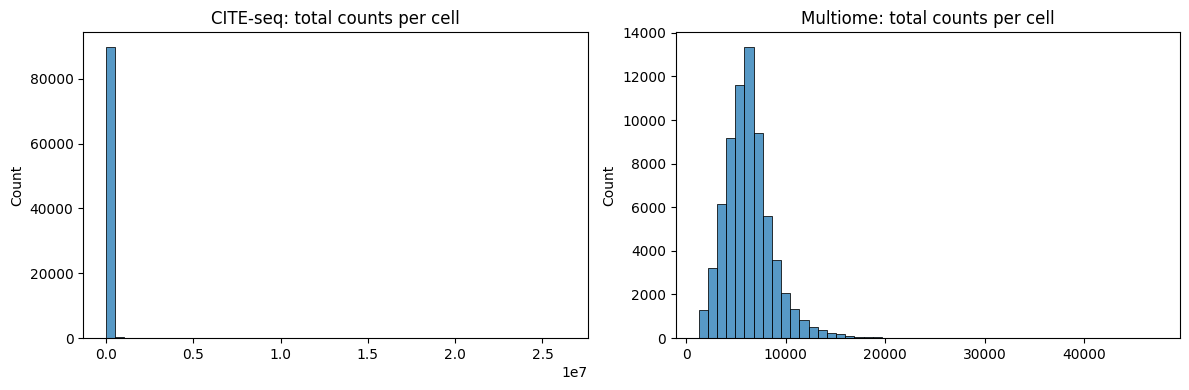

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

total_counts_cite = np.asarray(X.sum(axis=1)).flatten() if sp.issparse(X) else X.sum(axis=1)
sns.histplot(total_counts_cite, bins=50, ax=axes[0])
axes[0].set_title('CITE-seq: total counts per cell')

total_counts_multi = np.asarray(X2.sum(axis=1)).flatten() if sp.issparse(X2) else X2.sum(axis=1)
sns.histplot(total_counts_multi, bins=50, ax=axes[1])
axes[1].set_title('Multiome: total counts per cell')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb01_total_counts.png', dpi=150)
plt.show()

## Barcode overlap check
Confirms whether CITE-seq and Multiome share the same donors/cells, or are fully separate cell populations (expected for this benchmark).

In [27]:
common_barcodes = set(cite.obs_names) & set(multiome.obs_names)
print(f'CITE-seq cells: {cite.n_obs:,}')
print(f'Multiome cells: {multiome.n_obs:,}')
print(f'Common barcodes: {len(common_barcodes):,}')

CITE-seq cells: 90,261
Multiome cells: 69,249
Common barcodes: 0


In [28]:
print(multiome.var['feature_types'].value_counts())
print(multiome.uns['ATAC_gene_activity_var_names'][:10])

feature_types
ATAC    116490
GEX      13431
Name: count, dtype: int64
['OR4F5' 'OR4F29' 'OR4F16' 'SAMD11' 'NOC2L' 'KLHL17' 'PLEKHN1' 'PERM1'
 'HES4' 'ISG15']


## Summary findings
Fill in after running the cells above:
- X representation (raw/normalized/log): 
- Cell type annotations present: 
- Donor/batch columns: 
- Protein (ADT) location: 
- ATAC location: 
- Any cells shared between CITE-seq and Multiome: 